## Sales Performance Analysis

**The coffee-owner wants** to understand it's current Customers and increase Revenue:

*  What is the average basket size (qty x price) per transaction?   
*  What are the best-selling items by volume vs. by revenue?
*  Can we group transactions into meaningful spending tiers (low / mid / high spenders)?
    * What does the "typical" transaction look like for each segment?

In [ ]:
!pip install fg-data-profiling numpy pandas --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from data_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files


In [ ]:
# Config Style for Visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### Upload Dataset

In [ ]:
uploaded = files.upload()

Saving dirty_cafe_sales.csv to dirty_cafe_sales.csv


In [ ]:
# Load dataset
#df_raw = pd.read_excel("Totoros Analysis.xlsx")
df_raw = pd.read_csv("dirty_cafe_sales.csv")
print(f"Dataset shape: {df_raw.shape}")


Dataset shape: (10000, 8)


### Data Profiling
Familiaring with the data

In [ ]:
# Explore the Data: Front & Back
# Get a sense of the data
df_raw.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [ ]:
df_raw.tail(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9990,TXN_1538510,Coffee,5,2.0,10.0,Digital Wallet,NaN,2023-05-22
9991,TXN_3897619,Sandwich,3,4.0,12.0,Cash,Takeaway,2023-02-24
9992,TXN_2739140,Smoothie,4,4.0,16.0,UNKNOWN,In-store,2023-07-05
9993,TXN_4766549,Smoothie,2,4.0,NaN,Cash,NaN,2023-10-20
9994,TXN_7851634,UNKNOWN,4,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


## Data Profiling (EDA)

In [ ]:
profile = ProfileReport(df_raw, title="Profiling Report", explorative=True)

In [ ]:
profile.to_file("totoros_dataprofile_v2.html")
files.download("totoros_dataprofile_v2.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:01<00:00,  7.11it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Data Cleaning and Transformation

In [ ]:
# Standardize column names

"""
Chaining String Operations, break down:
df_copy.columns = df_copy.columns.str.replace(' ', '_')

#df_copy.columns.str.strip()

#df_copy.columns.str.lower()
"""

df_std_cols =  df_raw.columns.str.replace(' ','_').str.lower().str.strip()

df_coff_shop = df_raw.copy()
df_coff_shop.columns = df_std_cols

In [ ]:
# Rename the 'location' column to 'food_service'
df_coff_shop = df_coff_shop.rename(columns={"location": "food_service"})

# Check column name alteration
print(df_coff_shop.columns)

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'food_service', 'transaction_date'],
      dtype='object')


In [ ]:
# Cast Data Types
df_coff_shop["quantity"]       = pd.to_numeric(df_coff_shop["quantity"],       errors="coerce")
df_coff_shop["price_per_unit"] = pd.to_numeric(df_coff_shop["price_per_unit"], errors="coerce")
df_coff_shop["total_spent"]    = pd.to_numeric(df_coff_shop["total_spent"],    errors="coerce")
df_coff_shop["transaction_date"] = pd.to_datetime(df_coff_shop["transaction_date"], errors="coerce")

In [ ]:
# Useful derived information for analysis
# Date features
df_coff_shop["month"]     = df_coff_shop["transaction_date"].dt.month
df_coff_shop["month_name"] = df_coff_shop["transaction_date"].dt.strftime("%b")
df_coff_shop["day_of_week"] = df_coff_shop["transaction_date"].dt.day_name()

#### Inspect values from Casted Data Types

In [ ]:
# Table-Viz value distribution
df_coff_shop["price_per_unit"].value_counts(dropna=False)

,count
price_per_unit,
3.0,2429
4.0,2331
2.0,1227
5.0,1204
1.0,1143
1.5,1133
NaN,533


In [ ]:
df_coff_shop.groupby('item')['price_per_unit'].value_counts()

item      price_per_unit
Cake      3.0               1085
Coffee    2.0               1108
Cookie    1.0               1026
ERROR     3.0                 77
          4.0                 61
          5.0                 39
          1.5                 37
          1.0                 34
          2.0                 31
Juice     3.0               1110
Salad     5.0               1082
Sandwich  4.0               1082
Smoothie  4.0               1036
Tea       1.5               1023
UNKNOWN   3.0                 77
          4.0                 70
          2.0                 49
          1.0                 45
          5.0                 45
          1.5                 40
Name: count, dtype: int64

#### From the Item by "Price per Unit" table

I can infer what the "price per unit" for each item is and therefore update ERROR and UNKNOWN, item, records. Specially since there are no other "different values" within those two categorical names, e.i.: 1.0, 1.5, 2.0, 3.0, 4.0, 5.0

The only exception will be Sandwiches and Smoothies, item values, since both share the same "price per unit" of 4.0 and I have no other field nor data to accurately identify which of the two items the record refers to.

In [ ]:
# Recover ERROR and UNKNOWN Item records
item_mapping = {
    1.0: 'Cookie',
    1.5: 'Tea',
    2.0: 'Coffee',
    3.0: 'Cake',
    5.0: 'Salad'
}

# Apply the mapping for 'ERROR' and 'UNKNOWN' items based on 'price_per_unit'
for price, item_name in item_mapping.items():
    mask = (df_coff_shop['item'].isin(['ERROR', 'UNKNOWN'])) & (df_coff_shop['price_per_unit'] == price)
    df_coff_shop.loc[mask, 'item'] = item_name


# Verify the changes (optional)
print(df_coff_shop['item'].value_counts())
print(df_coff_shop.groupby('item')['price_per_unit'].value_counts())

item
Cake        1293
Coffee      1245
Salad       1232
Cookie      1171
Juice       1171
Tea         1166
Sandwich    1131
Smoothie    1096
UNKNOWN       88
ERROR         74
Name: count, dtype: int64
item      price_per_unit
Cake      3.0               1239
Coffee    2.0               1188
Cookie    1.0               1105
ERROR     4.0                 61
Juice     3.0               1110
Salad     5.0               1166
Sandwich  4.0               1082
Smoothie  4.0               1036
Tea       1.5               1100
UNKNOWN   4.0                 70
Name: count, dtype: int64


In [ ]:
# Check: overall "Price per Unit" field value distribution
# Table-Viz value distribution
df_coff_shop["price_per_unit"].value_counts(dropna=False)

,count
price_per_unit,
3.0,2429
4.0,2331
2.0,1227
5.0,1204
1.0,1143
1.5,1133
NaN,533


In [ ]:
# Drop Unknown, Error leftover records
items_to_drop = ['UNKNOWN', 'ERROR']
df_coff_shop = df_coff_shop[~df_coff_shop['item'].isin(items_to_drop)]

In [ ]:
# Check: overall "Price per Unit" field value distribution
# Table-Viz value distribution
df_coff_shop["price_per_unit"].value_counts(dropna=False)

,count
price_per_unit,
3.0,2429
4.0,2200
2.0,1227
5.0,1204
1.0,1143
1.5,1133
NaN,502


In [ ]:
# Drop records from Dataframe where 'price_per_unit' is NaN
df_coff_shop = df_coff_shop.dropna(subset=['price_per_unit'])

print("Shape of DataFrame after dropping NaN in 'price_per_unit':", df_coff_shop.shape)
print("\nValue counts of 'price_per_unit' after dropping NaNs:")
print(df_coff_shop['price_per_unit'].value_counts(dropna=False))

Shape of DataFrame after dropping NaN in 'price_per_unit': (9336, 11)

Value counts of 'price_per_unit' after dropping NaNs:
price_per_unit
3.0    2429
4.0    2200
2.0    1227
5.0    1204
1.0    1143
1.5    1133
Name: count, dtype: int64


In [ ]:
# Check: Viz 'quantity' value distribution
df_coff_shop['quantity'].value_counts(dropna=False)

,count
quantity,
5.0,1861
2.0,1842
4.0,1739
3.0,1732
1.0,1713
NaN,449


In [ ]:
# Drop records from Dataframe where 'quantity' is NaN
df_coff_shop = df_coff_shop.dropna(subset=['quantity'])

print("Shape of DataFrame after dropping NaN in 'quantity':", df_coff_shop.shape)
print("\nValue counts of 'quantity' after dropping NaNs:")
print(df_coff_shop['quantity'].value_counts(dropna=False))

Shape of DataFrame after dropping NaN in 'quantity': (8887, 11)

Value counts of 'quantity' after dropping NaNs:
quantity
5.0    1861
2.0    1842
4.0    1739
3.0    1732
1.0    1713
Name: count, dtype: int64


In [ ]:
# Check: Viz 'item' value distribution
df_coff_shop['item'].value_counts(dropna=False)

,count
item,
Cake,1191
Coffee,1121
Salad,1111
Juice,1063
Cookie,1051
Tea,1041
Sandwich,1022
Smoothie,994
NaN,293


In [ ]:
# Drop records from Dataframe where 'item' is NaN
df_coff_shop = df_coff_shop.dropna(subset=['item'])

print("Shape of DataFrame after dropping NaN in 'item':", df_coff_shop.shape)
print("\nValue counts of 'item' after dropping NaNs:")
print(df_coff_shop['item'].value_counts(dropna=False))

Shape of DataFrame after dropping NaN in 'item': (8594, 11)

Value counts of 'item' after dropping NaNs:
item
Cake        1191
Coffee      1121
Salad       1111
Juice       1063
Cookie      1051
Tea         1041
Sandwich    1022
Smoothie     994
Name: count, dtype: int64


In [ ]:
# Check: Viz 'transaction_date' value distribution
df_coff_shop['transaction_date'].value_counts(dropna=False)

,count
transaction_date,
NaT,388
2023-07-21,36
2023-07-24,35
2023-06-30,34
2023-03-13,34
...,...
2023-07-30,13
2023-03-11,13
2023-02-17,12


In [ ]:
# Drop records from Dataframe where 'transaction_date' is NaN
df_coff_shop = df_coff_shop.dropna(subset=['transaction_date'])

print("Shape of DataFrame after dropping NaT in 'transaction_date':", df_coff_shop.shape)
print("\nValue counts of 'transaction_date' after dropping NaNs:")
print(df_coff_shop['transaction_date'].value_counts(dropna=False))

Shape of DataFrame after dropping NaT in 'transaction_date': (8206, 11)

Value counts of 'transaction_date' after dropping NaNs:
transaction_date
2023-07-21    36
2023-07-24    35
2023-06-16    34
2023-06-30    34
2023-03-13    34
              ..
2023-04-22    13
2023-03-11    13
2023-02-17    12
2023-08-08    12
2023-04-27    11
Name: count, Length: 365, dtype: int64


In [ ]:
# Recalculate the "total_spent", derived from Quantity and Price_per_Unit
# Augment dataframe with new col: "total_spent_derived"

df_coff_shop['total_spent_derived'] = df_coff_shop['quantity'] * df_coff_shop['price_per_unit']


In [ ]:
# Check: total_spend_derived NaN values
# I Expect: 0
nan_count = df_coff_shop['total_spent_derived'].isnull().sum()
print(f"Number of NaN values in 'total_spent_derived': {nan_count}")

Number of NaN values in 'total_spent_derived': 0


In [ ]:
# Check: Stare & Compare: Total Spent vs Total Spent Derived
display(df_coff_shop[['total_spent', 'total_spent_derived']].tail(10))

,total_spent,total_spent_derived
9986,8.0,8.0
9987,15.0,15.0
9989,15.0,15.0
9990,10.0,10.0
9991,12.0,12.0
9992,16.0,16.0
9993,NaN,8.0
9995,4.0,4.0
9997,8.0,8.0
9999,12.0,12.0


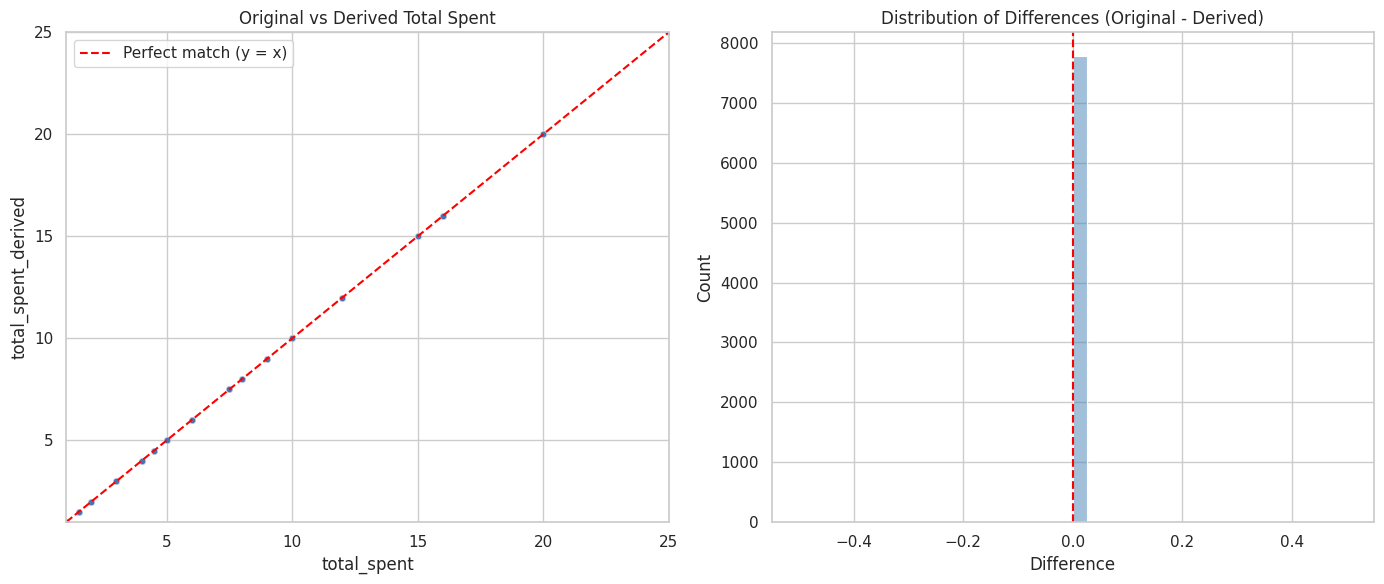

Rows with mismatch: 0 / 8206 (0.00%)
count    7790.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: diff, dtype: float64


In [ ]:
"""
Visualize Total Spent vs Total Spent Derived

  1) Scatter Plot of derived vs. original with a 45° reference line (y = x)
      Every row where the two values match perfectly lands exactly on the
      diagonal; anything off the line is an immediate visual flag for a
      Data Quality issue (missing discount, tax diff., data entry error, etc.)

  2) Histogram of the differences (total_spent - total_spent_derived)
     Tells you not just that there are mismatches, but how big and
     how frequent they are
"""
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Scatter plot with y = x reference line
ax = axes[0]
sns.scatterplot(
    data=df_coff_shop, x="total_spent", y="total_spent_derived",
    alpha=0.4, s=20, ax=ax
)

# interval limits
lims = [
    min(df_coff_shop["total_spent"].min(), df_coff_shop["total_spent_derived"].min()),
    max(df_coff_shop["total_spent"].max(), df_coff_shop["total_spent_derived"].max())
]

ax.plot(lims, lims, color="red", linestyle="--", linewidth=1.5, label="Perfect match (y = x)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Original vs Derived Total Spent")
ax.legend()

# 2. Histogram of differences
df_coff_shop["diff"] = df_coff_shop["total_spent"] - df_coff_shop["total_spent_derived"]
sns.histplot(df_coff_shop["diff"], bins=40, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Distribution of Differences (Original - Derived)")
axes[1].set_xlabel("Difference")

plt.tight_layout()
plt.show()

# Quick summary stats on the mismatches
mismatches = df_coff_shop[df_coff_shop["diff"].abs() > 0.05]
print(f"Rows with mismatch: {len(mismatches)} / {len(df_coff_shop)} ({len(mismatches)/len(df_coff_shop):.2%})")
print(df_coff_shop["diff"].describe())

In [ ]:
# Handling Missing values
# Print Proportions %
missing = df_coff_shop.isnull().mean() * 100
print(missing[missing > 0].sort_values(ascending=False))

food_service      32.719961
payment_method    25.542286
total_spent        5.069461
diff               5.069461
dtype: float64


In order to preserve the maximum number of sales records: Food Service (formerly Location) and Payment Menthod fields will retain their NaN values. I will transform them into "Unknown" values.

On the other hand, the Total Spent field will be kept, but it will not be used. Its derived field will be used instead.



In [ ]:
# Check for Duplicated records (i.e. two equal record-rows)
n_dupes = df_coff_shop.duplicated().sum()
n_dupes

# Result: No duplicate records

np.int64(0)

In [ ]:
# Fill Missing values with "Unknown" value
categorical_cols = ['food_service', 'payment_method']
df_coff_shop[categorical_cols] = df_coff_shop[categorical_cols].fillna("Unknown")


In [ ]:
# Check
df_coff_shop['food_service'].value_counts(dropna=False)

,count
food_service,
Unknown,2685
In-store,2475
Takeaway,2470
ERROR,298
UNKNOWN,278


In [ ]:
# Unify unknown values in "food_service" field
dirty_vals = ["ERROR", "UNKNOWN"]

# New approach that adheres to Pandas API:
# cleaner, warning-free, and makes the assignment explicit
df_coff_shop['food_service'] = df_coff_shop['food_service'].replace(dirty_vals, "Unknown")

In [ ]:
# Verify if the 'food_service' Unification was done correctly
print("Shape of DataFrame after unifying unknown values in 'food_service':", df_coff_shop.shape)
print("\nValue counts of 'food_service' after unknown value unification:")
print(df_coff_shop['food_service'].value_counts(dropna=False))

Shape of DataFrame after unifying unknown values in 'food_service': (8206, 13)

Value counts of 'food_service' after unknown value unification:
food_service
Unknown     3261
In-store    2475
Takeaway    2470
Name: count, dtype: int64


In [ ]:
# Check
df_coff_shop['payment_method'].value_counts(dropna=False)

,count
payment_method,
Unknown,2096
Digital Wallet,1885
Cash,1871
Credit Card,1857
ERROR,254
UNKNOWN,243


In [ ]:
# Unify unknown values in "payment_method" field
dirty_vals = ["ERROR", "UNKNOWN"]

# New approach that adheres to Pandas API:
# cleaner, warning-free, and makes the assignment explicit
df_coff_shop['payment_method'] = df_coff_shop['payment_method'].replace(dirty_vals, "Unknown")

In [ ]:
# Verify if the 'payment_method' Unification was done correctly
print("Shape of DataFrame after unifying unknown values in 'payment_method':", df_coff_shop.shape)
print("\nValue counts of 'payment_method' after unknown value unification:")
print(df_coff_shop['payment_method'].value_counts(dropna=False))

Shape of DataFrame after unifying unknown values in 'payment_method': (8206, 13)

Value counts of 'payment_method' after unknown value unification:
payment_method
Unknown           2593
Digital Wallet    1885
Cash              1871
Credit Card       1857
Name: count, dtype: int64


## Summary Statistics

### Analytics Layer 1: Descriptive -- What happened?

### Numeric Summary

In [ ]:
print("=== Numeric Summary ===")
df_coff_shop[["quantity", "price_per_unit", "total_spent_derived"]].describe().round(2)

=== Numeric Summary ===


,quantity,price_per_unit,total_spent_derived
count,8206.00,8206.00,8206.00
mean,3.02,2.94,8.87
std,1.42,1.28,5.98
min,1.00,1.00,1.00
25%,2.00,2.00,4.00
50%,3.00,3.00,8.00
75%,4.00,4.00,12.00
max,5.00,5.00,25.00


#### Descriptive Summary Statistics: Number Variables

* Number of Sales records: 8,206
* The values between the "mean" and "median" are approximately the same, with the mean slightly under for "price per unit" field, up for "quantity", and almost a whole dollar for "total_spent_derived" (basket_purchase).
   * This tells us that the distribution of the data set is approximately normally distributed.
* Quartile values between "quantity" and "price per unit" fields seem to be directly proportional.
   * Whereas "total spent derived" quartile values are at least x2 or more the value from the other numeric variables.

### Revenue & Volume by Item

In [ ]:
item_summary = df_coff_shop.groupby("item").agg(
    transactions = ("transaction_id", "count"),
    total_revenue = ("total_spent_derived", "sum"),
    avg_basket    = ("total_spent_derived", "mean"),
    median_basket = ("total_spent_derived", "median"),
    avg_qty       = ("quantity", "mean")
).sort_values("total_revenue", ascending=False).round(2)

display(item_summary)

,transactions,total_revenue,avg_basket,median_basket,avg_qty
item,,,,,
Salad,1061,15970.0,15.05,15.0,3.01
Sandwich,969,11680.0,12.05,12.0,3.01
Smoothie,951,11608.0,12.21,12.0,3.05
Cake,1135,10323.0,9.10,9.0,3.03
Juice,1020,9108.0,8.93,9.0,2.98
Coffee,1083,6614.0,6.11,6.0,3.05
Tea,986,4471.5,4.53,4.5,3.02
Cookie,1001,2991.0,2.99,3.0,2.99


In [ ]:
# Sorting each descriptive value from Revenue & Volume by Item
df_coff_shop.groupby("item")["total_spent_derived"].sum().sort_values(ascending=False)

,total_spent_derived
item,
Salad,15970.0
Sandwich,11680.0
Smoothie,11608.0
Cake,10323.0
Juice,9108.0
Coffee,6614.0
Tea,4471.5
Cookie,2991.0


#### Descriptive Stats: Revenue & Volume by Item
The average and median statistics for every item per basket for the whole year have closely the same value. We could assume that the observations (or events) are "normaly distributed" and there seems to be a lack of strong outliers within the yearly dataset.

Seems that, on average, a quantity of three "selected items" are taken per (basket) purchase.

#### Bulk Buying Behavior

The results indicate consistent transactions across all items.

The median quantity for most items is around 3, with the majority of transactions ranging from 2 to 4 units. The minimum quantity is 1 and the maximum is 5 for all items, indicating a relatively uniform distribution of purchase quantities regardless of the specific item.

Thus, **no bulk buying behavior**.

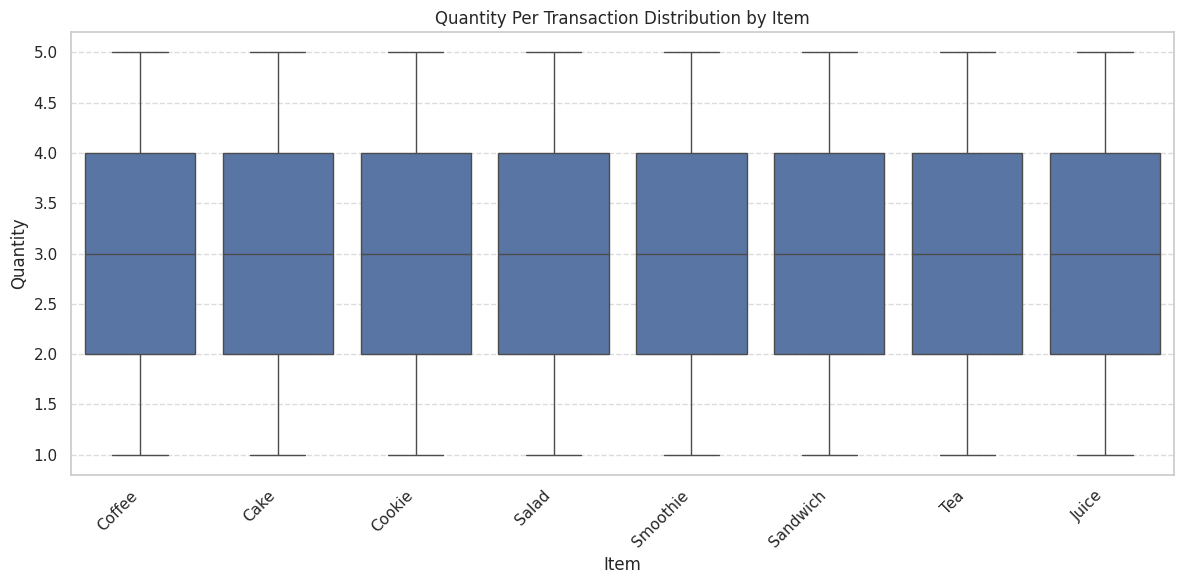

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='item', y='quantity', data=df_coff_shop)
plt.title('Quantity Per Transaction Distribution by Item')
plt.xlabel('Item')
plt.ylabel('Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

### Visualize Revenue & Volume by Item

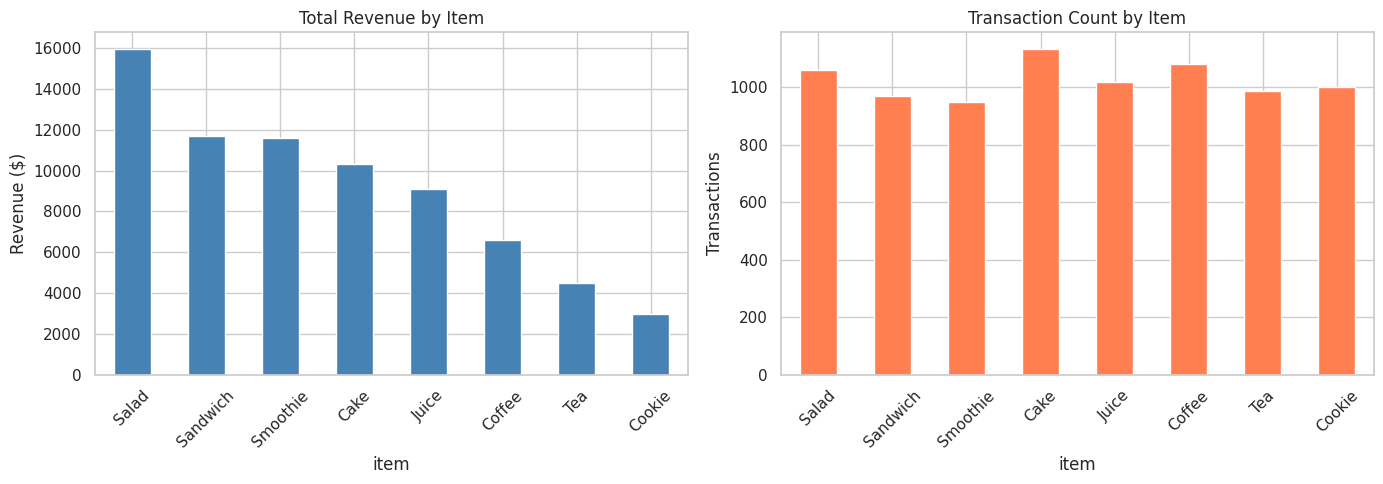

In [ ]:
# creates a FIGURE containing a GRID of SUBPLOTS (i.e. 1D Array)
# FIGURE: the entire Canvas/Container
# Why? One figure, two aligned, evenly-sized plots, easy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot on the Left subplot
item_summary["total_revenue"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Revenue by Item")
axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis="x", rotation=45)

# Plot on the Right subplot
item_summary["transactions"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Transaction Count by Item")
axes[1].set_ylabel("Transactions")
axes[1].tick_params(axis="x", rotation=45)

# Prevent subplot titles/labels to overlap
plt.tight_layout()
plt.show()

When comparing the number of transactions vs the total revenue per Item, the insights are as follows:

1. The "salad" item is the product that yields the highest margin of profit. "Salad" sold less than "Cake" item but it returned approximately USD 5,000 more that "Cake".
2. "Sandwich" sold slightly more than "Smoothie", yet their profits seems to be about the same amount. (No significant difference).
3. "Juice", "Tea", and "Cookie" sold more than "Sandwiches" and "Smoothies" yet their revenue was less than USD 10,000.
4. "Coffee" sold more thant "Juice", "Tea", and "Cookie" items, yet it yield a low revenue: a bit more than USD 6,000.

---

- Seems that "Salad" is the item to leverage to maximize profit. Or position as the most popular item in the shop.
- Secondly, "Sandwich" and "Smoothies" are the next items with potential to increase revenue. Just not as profitable as "Salads", yet great complement.



### Monthly Revenue Trend

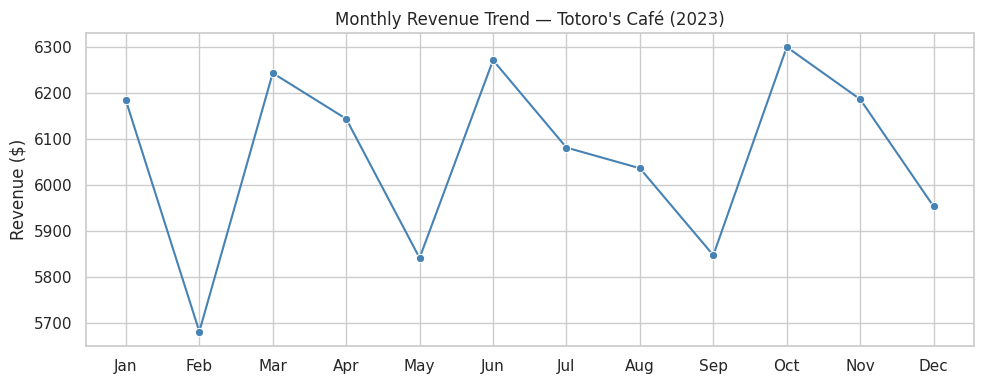

In [ ]:
monthly = df_coff_shop.groupby("month")["total_spent_derived"].sum().reset_index()
monthly["month_name"] = pd.to_datetime(monthly["month"], format="%m").dt.strftime("%b")

# New viz chart
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly, x="month_name", y="total_spent_derived", marker="o", color="steelblue")
plt.title("Monthly Revenue Trend — Totoro's Café (2023)")
plt.ylabel("Revenue ($)")
plt.xlabel("")
plt.tight_layout() # prevent overlapping titles/labels
plt.show()

#### Time Series Analysis: Revenue Trend - Monthly

* Deeper analysis (Zoom In) on February, May and September months.

   *  Understand WHY of the valleys.

#### Transaction & Revenue by Day

,transactions,total_revenue
day_of_week,,
Friday,1177,10451.0
Monday,1215,10597.5
Saturday,1177,10430.0
Sunday,1181,10565.5
Thursday,1186,10482.0
Tuesday,1130,10324.0
Wednesday,1140,9915.5


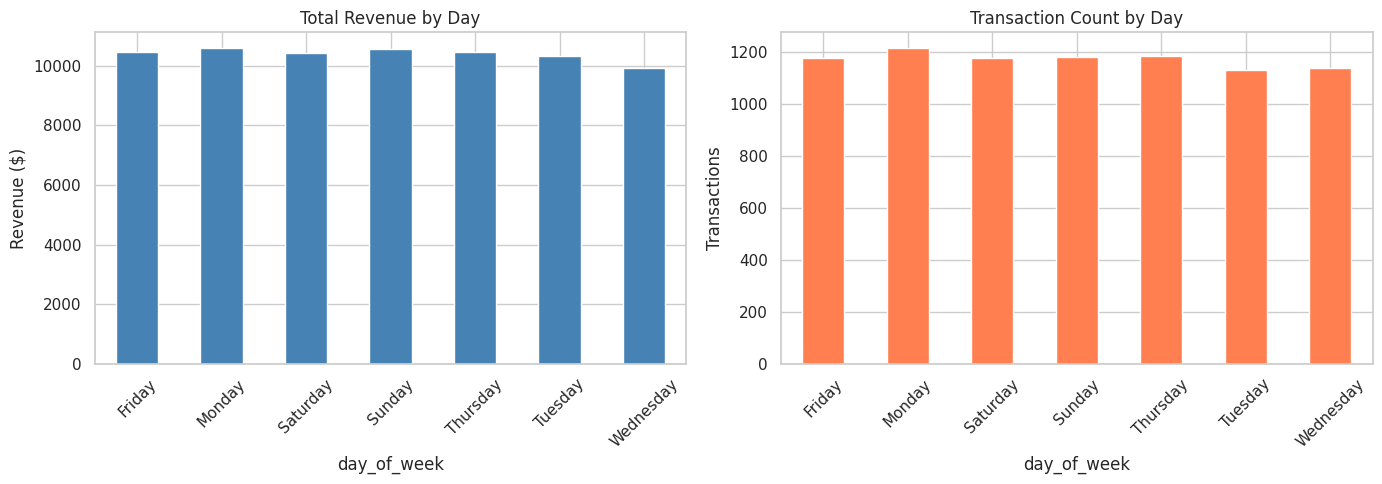

In [ ]:
daily = df_coff_shop.groupby("day_of_week").agg(
    transactions = ("transaction_id", "count"),
    total_revenue = ("total_spent_derived", "sum"),
).round(2)

display(daily)

#daily = df_coff_shop.groupby("day")["total_spent_derived"].sum().reset_index()
#daily["day_name"] = pd.to_datetime(daily["day"], format="%d").dt.strftime("%b")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot on the Left subplot
daily["total_revenue"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Revenue by Day")
axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis="x", rotation=45)

# Plot on the Right subplot
daily["transactions"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Transaction Count by Day")
axes[1].set_ylabel("Transactions")
axes[1].tick_params(axis="x", rotation=45)

# Prevent subplot titles/labels to overlap
plt.tight_layout()
plt.show()

#### Transaction & Revenue by Day: Peak Months
March, June, October

1. Friday: USD 3.072, 351 transactions
2. Thursday: USD 2.937, 335 transactions
3. Tuesday: USD 2.867.5, 308 transactions

,transactions,total_revenue
day_of_week,,
Friday,351,3072.5
Monday,303,2522.0
Saturday,267,2389.0
Sunday,300,2723.0
Thursday,335,2937.0
Tuesday,308,2867.5
Wednesday,269,2302.5


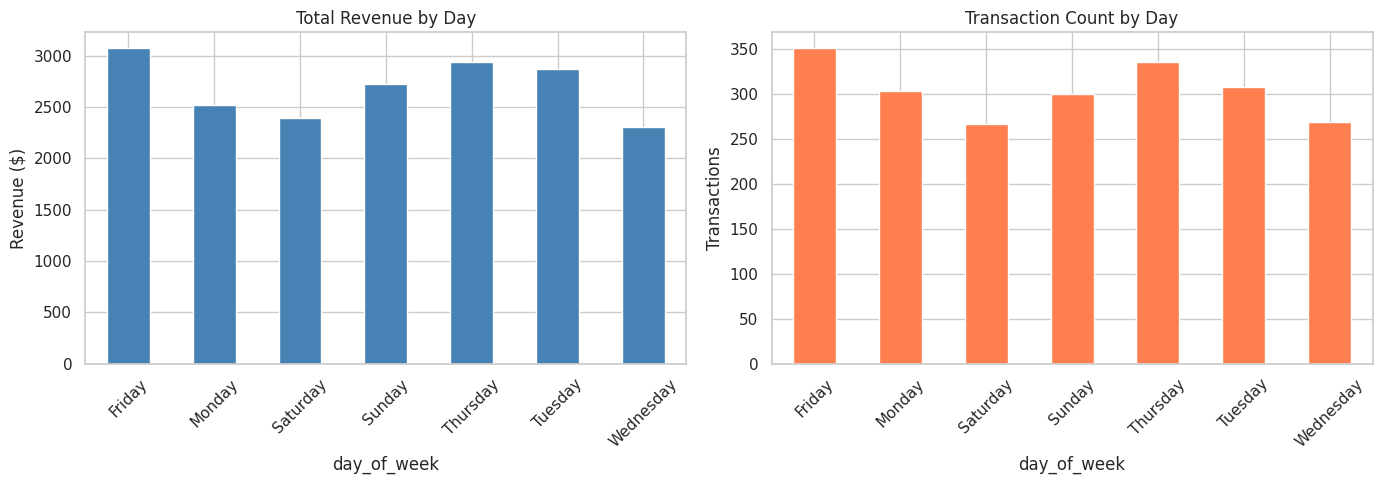

In [ ]:
peak_months = ["Mar", "Jun", "Oct"]
peak_months_df = df_coff_shop[df_coff_shop["month_name"].isin(peak_months)]

daily_peak_months = peak_months_df.groupby("day_of_week").agg(
    transactions = ("transaction_id", "count"),
    total_revenue = ("total_spent_derived", "sum"),
).round(2)

display(daily_peak_months)

# Graph: Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot on the Left subplot
daily_peak_months["total_revenue"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Revenue by Day")
axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis="x", rotation=45)

# Plot on the Right subplot
daily_peak_months["transactions"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Transaction Count by Day")
axes[1].set_ylabel("Transactions")
axes[1].tick_params(axis="x", rotation=45)

# Prevent subplot titles/labels to overlap
plt.tight_layout()
plt.show()

#### Transaction & Revenue by Day: Valley Months
Feb, May, September

1. Tuesday: USD 1.822, 197 transactions
2. Monday: USD 1.811.5, 218 transactions
3. Saturday: USD 1.741, 180 transactions

,transactions,total_revenue
day_of_week,,
Friday,160,1399.5
Monday,218,1811.5
Saturday,180,1741.5
Sunday,167,1530.5
Thursday,176,1611.0
Tuesday,197,1822.0
Wednesday,195,1606.0


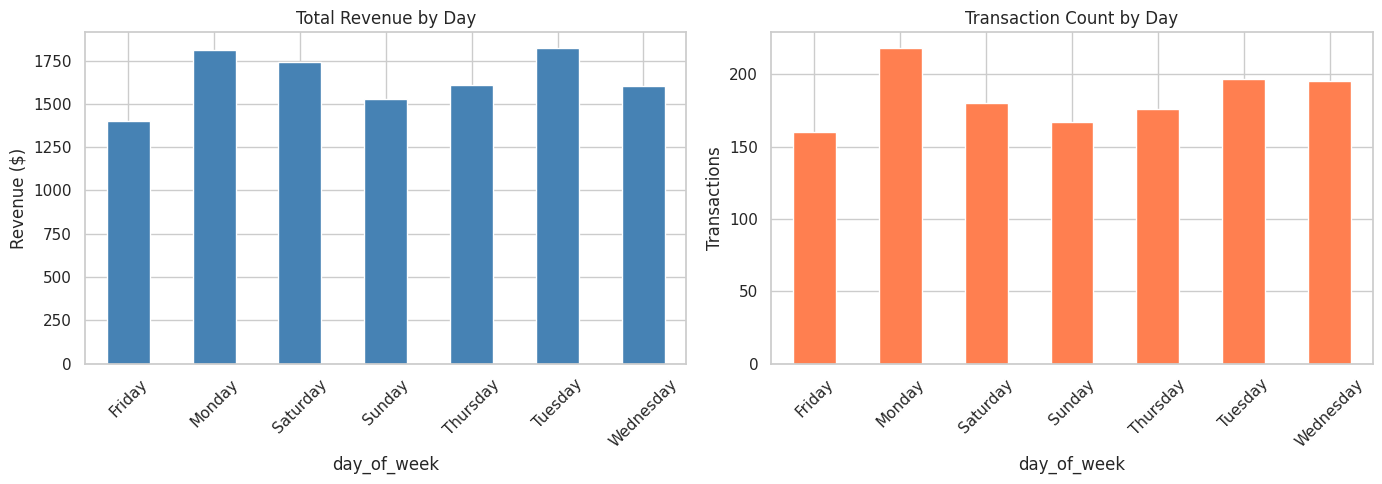

In [ ]:
valley_months = ["Feb", "May", "September"]
valley_months_df = df_coff_shop[df_coff_shop["month_name"].isin(valley_months)]

daily_valley_months = valley_months_df.groupby("day_of_week").agg(
    transactions = ("transaction_id", "count"),
    total_revenue = ("total_spent_derived", "sum"),
).round(2)

display(daily_valley_months)

# Graph: Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot on the Left subplot
daily_valley_months["total_revenue"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Revenue by Day")
axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis="x", rotation=45)

# Plot on the Right subplot
daily_valley_months["transactions"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Transaction Count by Day")
axes[1].set_ylabel("Transactions")
axes[1].tick_params(axis="x", rotation=45)

# Prevent subplot titles/labels to overlap
plt.tight_layout()
plt.show()

#### Are there seasonal peaks for specific items (e.g., Smoothies in summer, Tea in winter)?

The heatmap visually represents the revenue generated by each item across different months, helping to identify seasonal peaks.

- Spring:
   1. Salad: every month
   2. Sandwich: March, May
   3. Smoothie: April
- Summer:
   1. Salad: July
   2. Smoothie: June
   3. Sandwich: same revenue Jun, Jul, Aug

- Autumn:
   1. Salad: Peaks Nov, slightly less Oct
   2. Smoothie: Sep and Nov
   3. Cake: on Nov

- Winter:
   1. Salad: peaks Jan, slightly less on Dec
   2. Sandwich: on Jan
   3. Cake & Smoothie #3: Jan & Feb

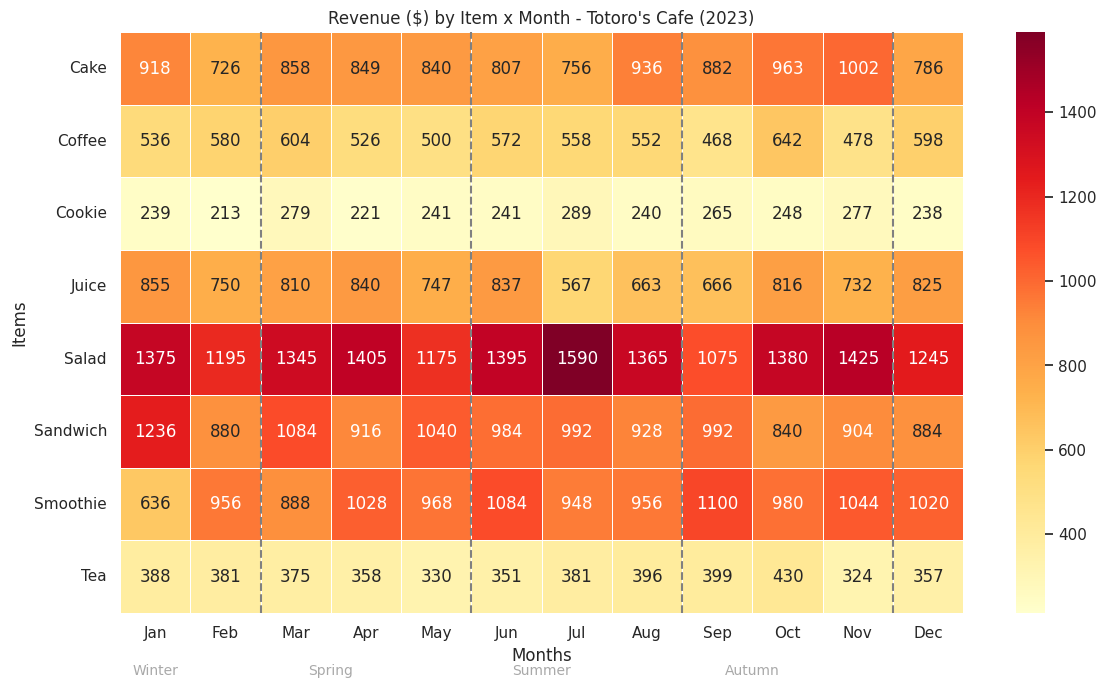

In [ ]:
# Seasonal peaks per Item
# Option 1: Vertical Lines with Annotations
monthly_item = df_coff_shop.groupby(["month", "item"])["total_spent_derived"].sum().reset_index()
monthly_item["month_name"] = pd.to_datetime(monthly_item["month"], format="%m").dt.strftime("%b")

pivot = monthly_item.pivot(
    index="item",
    columns="month_name",
    values="total_spent_derived"
  )

months_order = ["Jan","Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot = pivot[months_order]

plt.figure(figsize=(12, 7))
ax = sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Revenue ($) by Item x Month - Totoro's Cafe (2023)")
plt.xlabel("Months")
plt.ylabel("Items")

# Add vertical lines to delineate seasons
# Lines are placed at the boundaries between months (e.g., x=2 is between Feb and Mar)
ax.axvline(x=2, color='gray', linestyle='--', linewidth=1.5) # After Feb, before Mar (End of Winter)
ax.axvline(x=5, color='gray', linestyle='--', linewidth=1.5) # After May, before Jun (End of Spring)
ax.axvline(x=8, color='gray', linestyle='--', linewidth=1.5) # After Aug, before Sep (End of Summer)
ax.axvline(x=11, color='gray', linestyle='--', linewidth=1.5) # After Nov, before Dec (End of Autumn)

# Add text labels for seasons just below the x-axis labels
# The x-coordinates correspond to the month index (0-11) for the center of the column
# Winter spans Dec (11), Jan (0), Feb (1). We'll place the label between Jan and Feb.
ax.text(0.5, -0.1, 'Winter', ha='center', va='center', fontsize=10, color='darkgray', transform=ax.get_xaxis_transform())
# Spring spans Mar (2), Apr (3), May (4). Centered at 3.
ax.text(3, -0.1, 'Spring', ha='center', va='center', fontsize=10, color='darkgray', transform=ax.get_xaxis_transform())
# Summer spans Jun (5), Jul (6), Aug (7). Centered at 6.
ax.text(6, -0.1, 'Summer', ha='center', va='center', fontsize=10, color='darkgray', transform=ax.get_xaxis_transform())
# Autumn spans Sep (8), Oct (9), Nov (10). Centered at 9.
ax.text(9, -0.1, 'Autumn', ha='center', va='center', fontsize=10, color='darkgray', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

#### Food Service

In [ ]:
print("=== Revenue by Food Service ===")
revenue_x_food_service = df_coff_shop.groupby("food_service")["total_spent_derived"].agg(["sum","mean","count"]).round(2)
takeaway_sum = revenue_x_food_service.loc['Takeaway', 'sum']
revenue_x_food_service["%_of_total_sum"] = (revenue_x_food_service["sum"] / revenue_x_food_service["sum"].sum() * 100).round(2)
display(revenue_x_food_service)

=== Revenue by Food Service ===


,sum,mean,count,%_of_total_sum
food_service,,,,
In-store,22280.0,9.00,2475,30.62
Takeaway,21536.5,8.72,2470,29.60
Unknown,28949.0,8.88,3261,39.78


#### Revenue by Food Service - Insights

Consider rename field "Location" -to-> "Food Service" (done next iteration: 2026-07-26)

* "In-Store" generates %1.02 more revenue than "Takeaway".
* Notify coffee shop owner about system failures since almost ~40% of food service records are of type "Unknown".

In [ ]:
print("\n=== Revenue by Payment Method ===")
revenue_x_paymethod = df_coff_shop.groupby("payment_method")["total_spent_derived"].agg(["sum","mean","count"]).round(2)

revenue_x_paymethod["%_of_total_sum"] = (revenue_x_paymethod["sum"] / revenue_x_paymethod["sum"].sum() * 100).round(2)
display(revenue_x_paymethod)



=== Revenue by Payment Method ===


,sum,mean,count,%_of_total_sum
payment_method,,,,
Cash,16891.0,9.03,1871,23.21
Credit Card,16520.5,8.90,1857,22.70
Digital Wallet,16742.0,8.88,1885,23.01
Unknown,22612.0,8.72,2593,31.08


#### Revenue by Paymenth Method - Insights

* Most popular payment method: "Cash" (~%23.21 of all yearly transactions)
* Second: "Digital Wallet" (~%23.01)
* Third: "Credit Card" (~%22.70, roughly 0.30 - 0.5 percentage points below the top two popular payment methods)

#### Does payment method vary by Food Service? (e.g., Takeaway customers prefer Digital Wallet)

- Digital Wallet usage is slightly higher for Takeaway orders (35.7%) compared to In-store orders (33.4%). This aligns with the hypothesis that takeaway customers might prefer digital wallets for convenience.
- Cash payments are more prevalent for In-store orders (34.3%) than for Takeaway orders (31.7%).
- Credit Card usage is almost identical for both services, with 32.3% for In-store and 32.6% for Takeaway.

In summary, there is a subtle variation in payment method preference by food service: Takeaway customers show a slight preference for digital wallets, while in-store customers lean slightly more towards cash, with credit card usage being consistent across both.

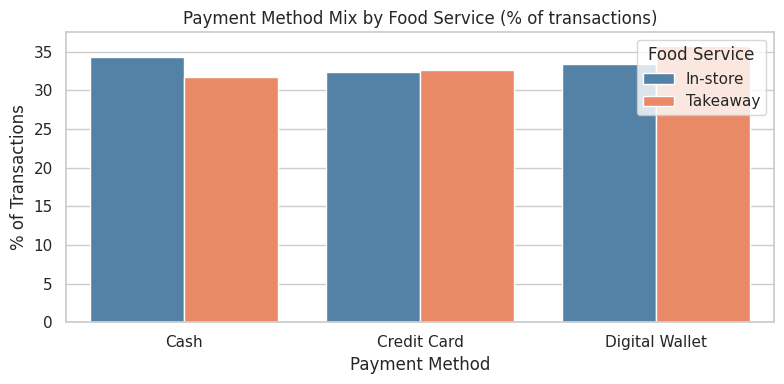

food_service    In-store  Takeaway
payment_method                    
Cash                34.3      31.7
Credit Card         32.3      32.6
Digital Wallet      33.4      35.7


In [ ]:
# Payment Method by Food Service
pay_food_serv = df_coff_shop[
    df_coff_shop["food_service"].isin(["In-store", "Takeaway"]) &
    df_coff_shop["payment_method"].isin(["Cash", "Credit Card", "Digital Wallet"])
]

ct = pd.crosstab(pay_food_serv["payment_method"], pay_food_serv["food_service"], normalize="columns") * 100
ct = ct.round(1)

# New Viz-Chart
plt.figure(figsize=(8, 4))
sns.barplot(data=ct.reset_index().melt(id_vars='payment_method', var_name='food_service', value_name='percentage'),
            x='payment_method', y='percentage', hue='food_service', palette=["steelblue", "coral"])
plt.title("Payment Method Mix by Food Service (% of transactions)")
plt.ylabel("% of Transactions")
plt.xlabel("Payment Method")
plt.xticks(rotation=0)
plt.legend(title="Food Service")
plt.tight_layout()
plt.show()

print(ct)

### Analytics Layer 2: Diagnostic -- Why did it happen?

Investigate the previous observations with **actual evidence**.

**Also, I believe, it is a good spot to formulate hypothesis to validate the behavior seen at the "Descriptive" layer.**

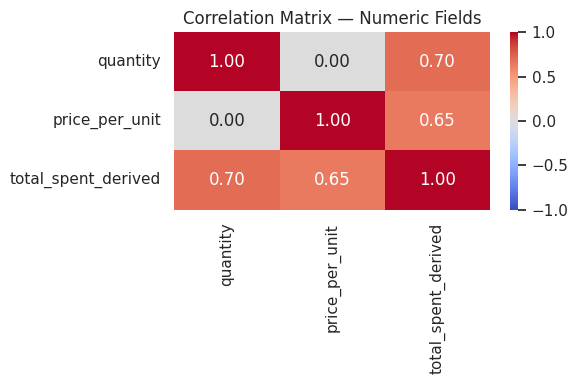

                     quantity  price_per_unit  total_spent_derived
quantity                1.000           0.002                0.701
price_per_unit          0.002           1.000                0.646
total_spent_derived     0.701           0.646                1.000


In [ ]:
# Correlation Matrix: quantity vs price?
# A visual that allows to see HOW "different Numerical variables"
# in the Dataset relate to one another
corr = df_coff_shop[["quantity", "price_per_unit", "total_spent_derived"]].corr()

# New viz-chart
plt.figure(figsize=(6, 4))
# annot = "annotate"
# Forces Seaborn to write the actual correlation numbers inside each square
# cmap = color map; coolwarm = uses a "diverging" color scheme
#   > Blues: Negative corr (one goes up, other goes down )
#   > White/Gray: Zero corr (no relationship)
#   > Reds: Positive corr (both goes up)
# VMIN, VMAX: ensure SNS anchors perfect corr values to the darkest color
#   Without this, Seaborn will auto-scale the colors based only on
#   the highest and lowest numbers it finds in your data
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Numeric Fields")
plt.tight_layout()
plt.show()

print(corr.round(3))

*Is the Quantity vs Price correlation real or just scale similarity?*
  
> Fields "Quantity" and "Price per Unit" **is real** since their **relationship strength is strong**

          avg_revenue_per_transaction  avg_quantity  avg_price_per_unit  \
item                                                                      
Salad                           15.05          3.01                 5.0   
Smoothie                        12.21          3.05                 4.0   
Sandwich                        12.05          3.01                 4.0   
Cake                             9.10          3.03                 3.0   
Juice                            8.93          2.98                 3.0   
Coffee                           6.11          3.05                 2.0   
Tea                              4.53          3.02                 1.5   
Cookie                           2.99          2.99                 1.0   

          total_revenue  transactions_count  
item                                         
Salad           15970.0                1061  
Smoothie        11608.0                 951  
Sandwich        11680.0                 969  
Cake            103

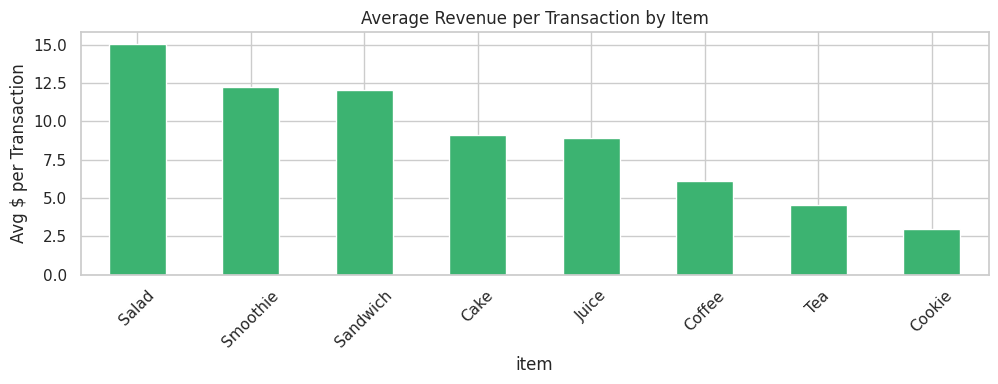

In [ ]:
# ITEM DEEP DIVE (Revenue Efficiency)?
# Revenue per Transaction and Avg-Quantity per Item
efficiency = df_coff_shop.groupby("item").agg(
    avg_revenue_per_transaction = ("total_spent_derived", "mean"),
    avg_quantity                = ("quantity", "mean"),
    avg_price_per_unit          = ("price_per_unit", "mean"),
    total_revenue               = ("total_spent_derived", "sum"),
    transactions_count          = ("transaction_id", "count")
).sort_values("avg_revenue_per_transaction", ascending=False).round(2)

# display table
print(efficiency)

# Visualize: average revenue per transaction (proxy for margin contribution)
efficiency["avg_revenue_per_transaction"].plot(
    kind="bar",
    color="mediumseagreen",
    figsize=(10, 4),
)
plt.title("Average Revenue per Transaction by Item")
plt.ylabel("Avg $ per Transaction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


*Does Smoothie actually lead in avg revenue per transaction?*

> No. Salad is actually the item that leads in average revenue per transaction.

Further Observations:   
> Salads, Sandwiches, and Smoothies do contribute higher revenue per transaction.  

> On the other end, "Cookies" return the lowest revenue per transaction.





#### [Zoom In] Is February a: volume problem, a basket size problem, or item-specific?

In [ ]:
# February Zoom-In (Lowest Valley)

feb = df_coff_shop[df_coff_shop["month"] == 2]

print(f"Feb # Transactions: {len(feb)}")
print(f"Full Year Avg # Transaction:  {len(df_coff_shop)/12:.0f}")

print(f"\nFeb Total Revenue: ${feb["total_spent_derived"].sum():,.2f}")


print(f"\nFeb revenue by item:")
print(feb.groupby("item")["total_spent_derived"].sum().sort_values(ascending=False))

# Compare Feb Avg Basket Value vs Full Year Avg Basket Value
print(f"\n -------Basket Value-------")
print(f"\nFull year Avg $ basket value: ${df_coff_shop['total_spent_derived'].mean():.2f}")
print(f"\nFull year Median basket value: ${df_coff_shop['total_spent_derived'].median():.2f}")
print(f"\nFeb Avg $ basket value:       ${feb['total_spent_derived'].mean():.2f}")
print(f"\nFeb Median basket value:       ${feb['total_spent_derived'].median():.2f}")

print(f"\n -------Basket Depth-------")
print(f"\nFeb Avg Quantity per Transaction: {feb['quantity'].mean():.2f}")
print(f"\nFeb Median Quantity per Transaction: {feb['quantity'].median():.2f}")
print(f"\nFull year Avg Quantity per Transaction: {df_coff_shop['quantity'].mean():.2f}")
print(f"\nFull year Median Quantity per Transaction: {df_coff_shop['quantity'].median():.2f}")


Feb # Transactions: 629
Full Year Avg # Transaction:  684

Feb Total Revenue: $5,681.00

Feb revenue by item:
item
Salad       1195.0
Smoothie     956.0
Sandwich     880.0
Juice        750.0
Cake         726.0
Coffee       580.0
Tea          381.0
Cookie       213.0
Name: total_spent_derived, dtype: float64

 -------Basket Value-------

Full year Avg $ basket value: $8.87

Full year Median basket value: $8.00

Feb Avg $ basket value:       $9.03

Feb Median basket value:       $8.00

 -------Basket Depth-------

Feb Avg Quantity per Transaction: 3.10

Feb Median Quantity per Transaction: 3.00

Full year Avg Quantity per Transaction: 3.02

Full year Median Quantity per Transaction: 3.00


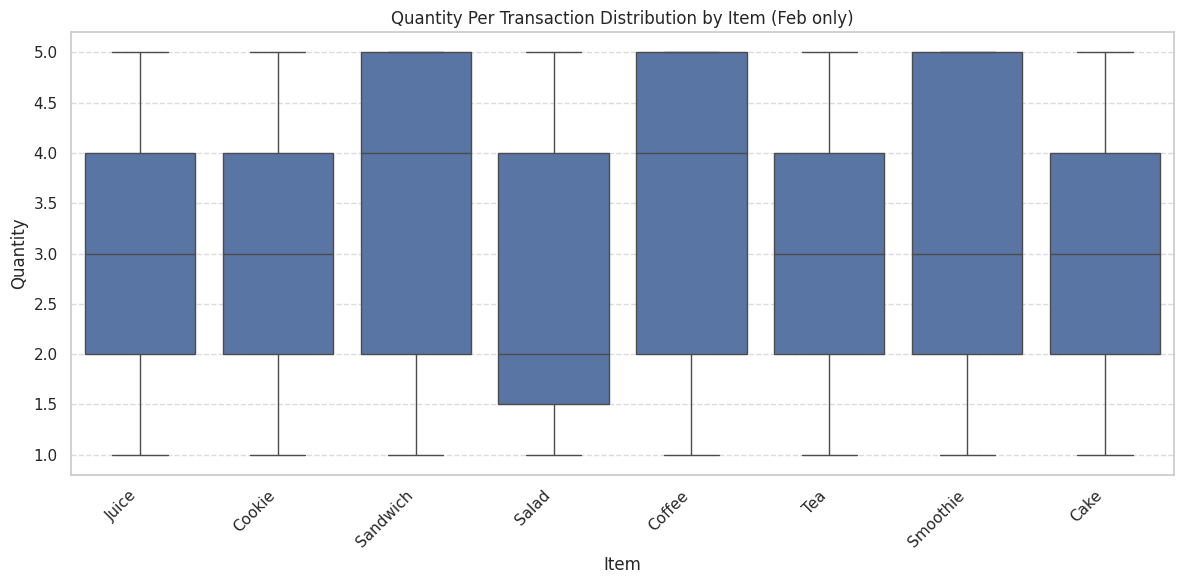

In [ ]:
# Visualize Item Specific Quantity per Transaction
plt.figure(figsize=(12, 6))
sns.boxplot(x='item', y='quantity', data=feb)
plt.title('Quantity Per Transaction Distribution by Item (Feb only)')
plt.xlabel('Item')
plt.ylabel('Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

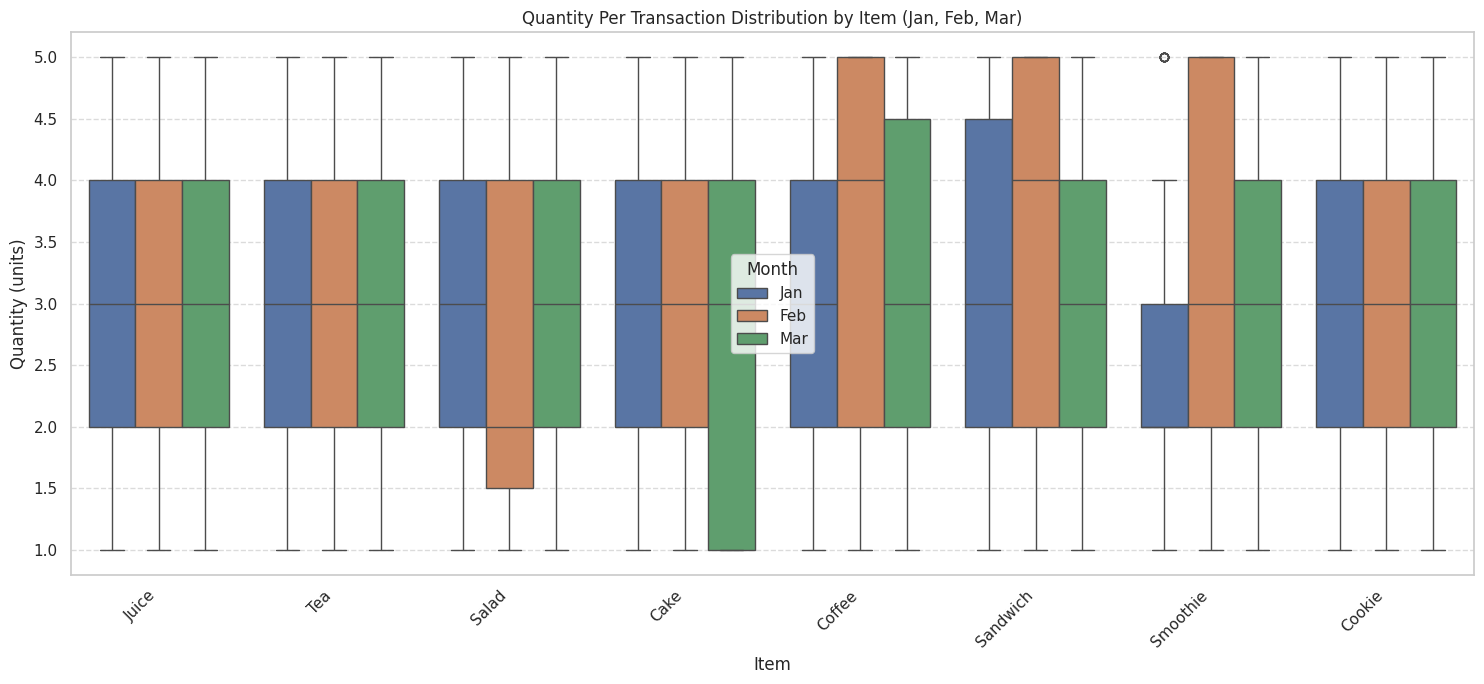

In [ ]:
# Prepare data for combined boxplot
jan_data = df_coff_shop[df_coff_shop["month"] == 1].copy()
jan_data["month_name"] = "Jan"
feb_data = df_coff_shop[df_coff_shop["month"] == 2].copy()
feb_data["month_name"] = "Feb"
mar_data = df_coff_shop[df_coff_shop["month"] == 3].copy()
mar_data["month_name"] = "Mar"

# Concatenate the data for the three months
combined_monthly_data = pd.concat([jan_data, feb_data, mar_data])

# Define the order of months for plotting
month_order = ["Jan", "Feb", "Mar"]

plt.figure(figsize=(15, 7))
sns.boxplot(
            x='item',
            y='quantity',
            hue='month_name',
            data=combined_monthly_data,
            palette='deep',
            order=combined_monthly_data['item'].unique(),
            hue_order=month_order
          )
plt.title('Quantity Per Transaction Distribution by Item (Jan, Feb, Mar)')
plt.xlabel('Item')
plt.ylabel('Quantity (units)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Month')
plt.tight_layout()
plt.show()

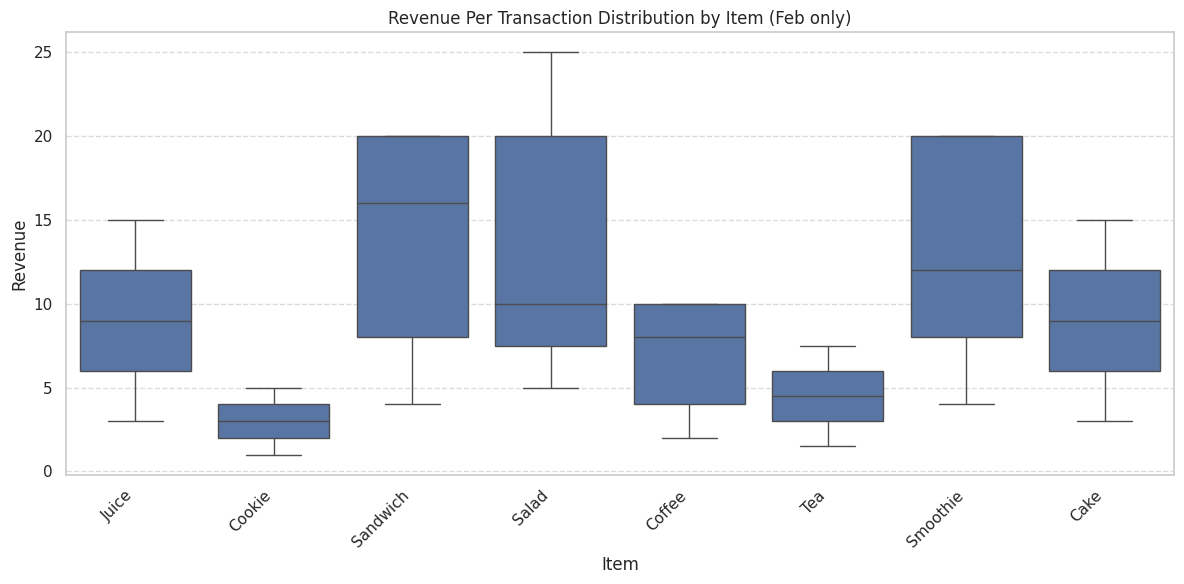

In [ ]:
# Visualize Item Specific Revenue per Transaction
plt.figure(figsize=(12, 6))
sns.boxplot(x='item', y='total_spent_derived', data=feb)
plt.title('Revenue Per Transaction Distribution by Item (Feb only)')
plt.xlabel('Item')
plt.ylabel('Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

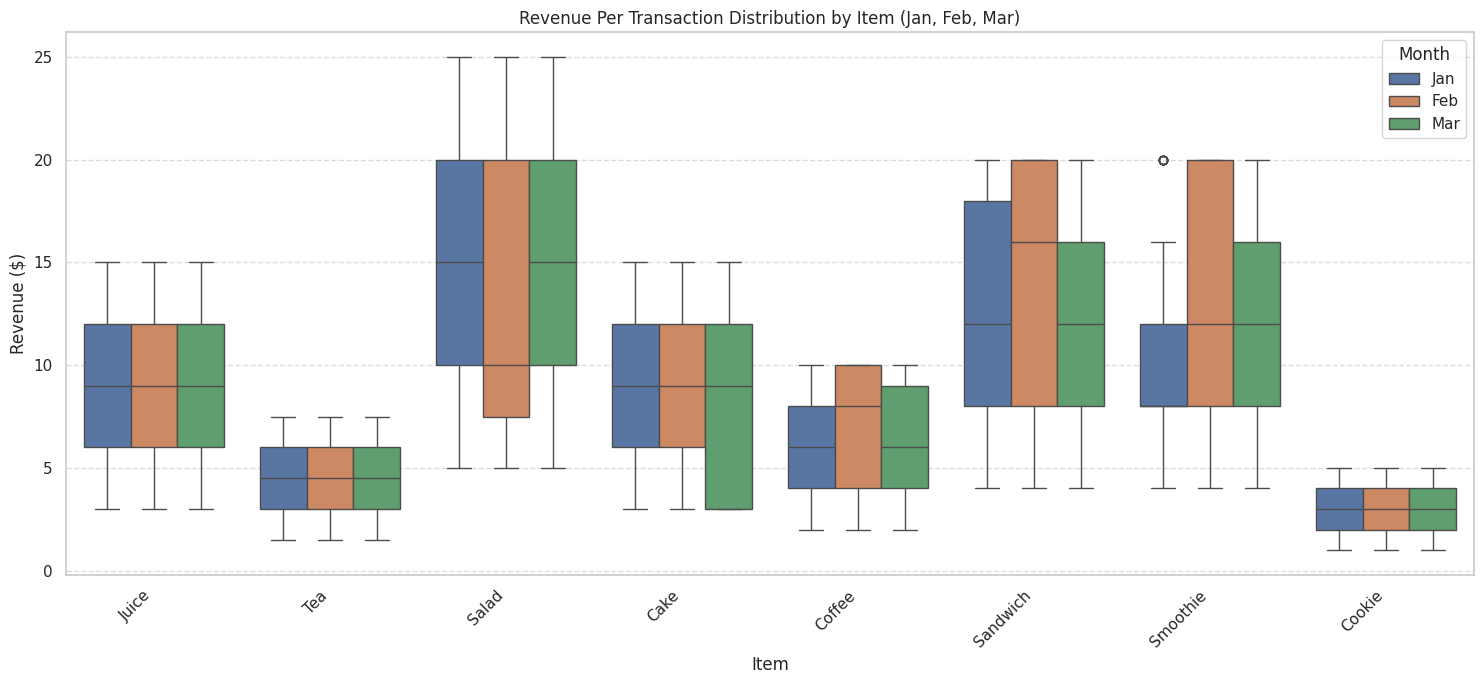

In [ ]:
# Graph: Visualize Item Specific Revenue per Transaction (Jan, Feb, Mar)

plt.figure(figsize=(15, 7))
sns.boxplot(x='item', y='total_spent_derived', hue='month_name', data=combined_monthly_data, palette='deep', order=combined_monthly_data['item'].unique(), hue_order=month_order)
plt.title('Revenue Per Transaction Distribution by Item (Jan, Feb, Mar)')
plt.xlabel('Item')
plt.ylabel('Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Month')

plt.tight_layout()
plt.show()

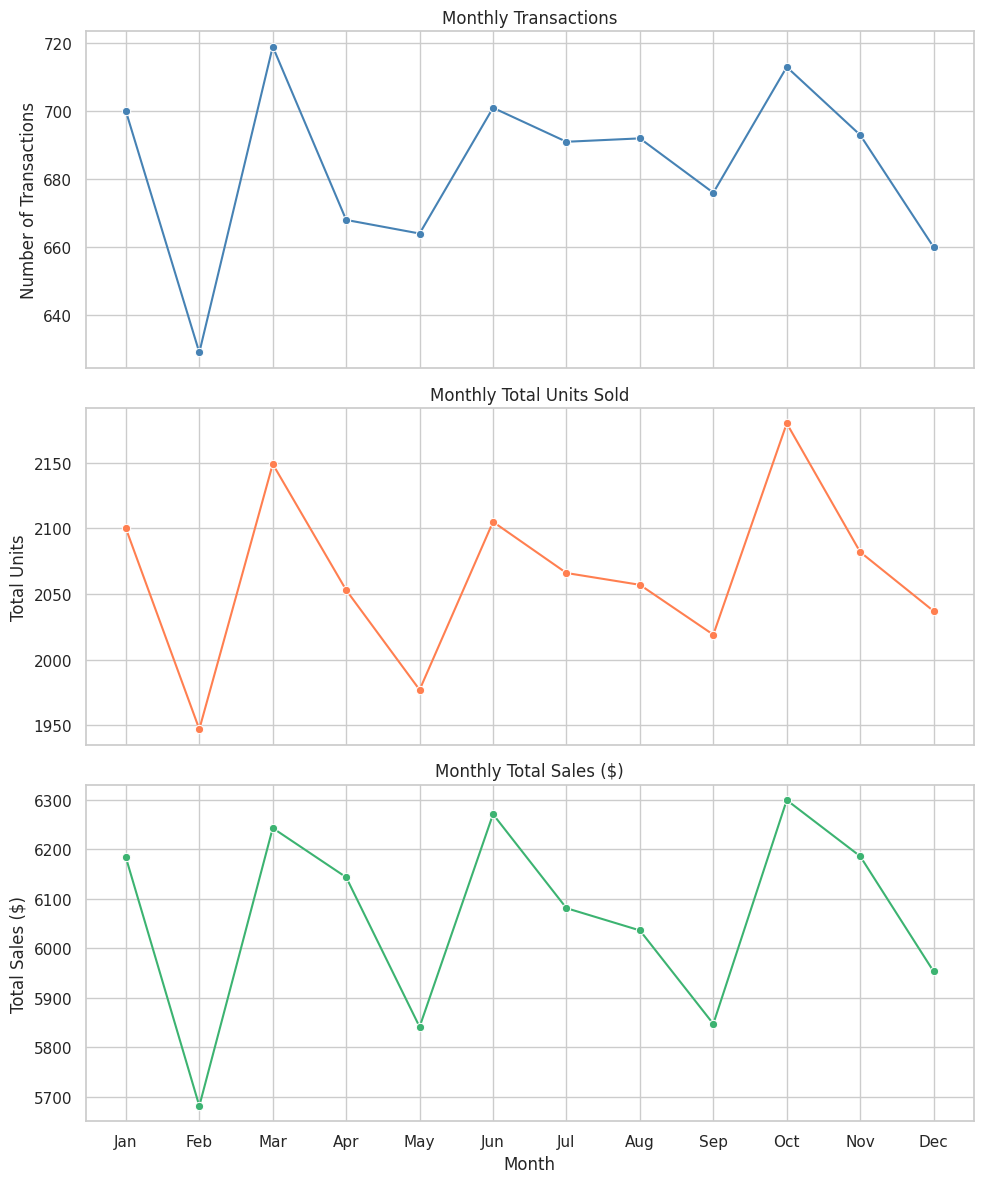

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by month and calculate total transactions, units, and sales
monthly_summary = df_coff_shop.groupby(["month", "month_name"]).agg(
    transactions = ("transaction_id", "count"),
    total_units = ("quantity", "sum"),
    total_sales = ("total_spent_derived", "sum")
).reset_index()

# Ensure month_name is in chronological order for plotting
months_order = ["Jan","Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_summary["month_name"] = pd.Categorical(monthly_summary["month_name"], categories=months_order, ordered=True)
monthly_summary = monthly_summary.sort_values("month_name")

# Create a figure with three subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Plot Monthly Transactions
sns.lineplot(data=monthly_summary, x="month_name", y="transactions", marker="o", color="steelblue", ax=axes[0])
axes[0].set_title("Monthly Transactions")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xlabel("") # Only last subplot needs x-label

# Plot Monthly Total Units Sold
sns.lineplot(data=monthly_summary, x="month_name", y="total_units", marker="o", color="coral", ax=axes[1])
axes[1].set_title("Monthly Total Units Sold")
axes[1].set_ylabel("Total Units")
axes[1].set_xlabel("")

# Plot Monthly Total Sales ($)
sns.lineplot(data=monthly_summary, x="month_name", y="total_sales", marker="o", color="mediumseagreen", ax=axes[2])
axes[2].set_title("Monthly Total Sales ($)")
axes[2].set_ylabel("Total Sales ($)")
axes[2].set_xlabel("Month")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()



In [ ]:
# Volume Numbers
print(f"\n ------- Volume of Transactions-------")
print(f"Number of Months in Dataset: {len(df_coff_shop["month"].unique())}")
print(f"\nFeb Volume of Transactions: {feb['transaction_id'].count():.2f}")
print(f"\nFull year Monthly Avg Volume of Transactions: {df_coff_shop['transaction_id'].count()/len(df_coff_shop["month"].unique()):.2f}")

print(f"\n ------- Volume of Total Units Sold -------")
print(f"\nFeb Volume of Total Units Sold: {feb['quantity'].sum():.2f}")
print(f"\nFull year Avg Volume of Total Units Sold: {df_coff_shop['quantity'].sum()/len(df_coff_shop["month"].unique()):.2f}")


print(f"\n ------- Volume of Revenue -------")
print(f"\nFeb Volume of Revenue: {feb['total_spent_derived'].sum():.2f}")
print(f"\nFull year Avg Volume of Revenue: {df_coff_shop['total_spent_derived'].sum()/len(df_coff_shop["month"].unique()):.2f}")



 ------- Volume of Transactions-------
Number of Months in Dataset: 12

Feb Volume of Transactions: 629.00

Full year Monthly Avg Volume of Transactions: 683.83

 ------- Volume of Total Units Sold -------

Feb Volume of Total Units Sold: 1947.00

Full year Avg Volume of Total Units Sold: 2064.33

 ------- Volume of Revenue -------

Feb Volume of Revenue: 5681.00

Full year Avg Volume of Revenue: 6063.79


In [ ]:
months_order = ["Jan","Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

month_totals = df_coff_shop.groupby("month")["total_spent_derived"].agg(["count", "sum"]).round(2).reset_index()
month_totals["month_name"] = pd.to_datetime(month_totals["month"], format="%m").dt.strftime("%b")

# Create a pivot table with 'count' and 'sum' as rows and months as columns
pivot2 = month_totals.set_index('month_name')[['count', 'sum']].T
pivot2 = pivot2.reindex(columns=months_order)

display(pivot2)

#
full_year_avg_revenue = df_coff_shop['total_spent_derived'].sum() / len(months_order)

print(f"\nFull year avg Revenue: ${(full_year_avg_revenue):.2f}")
print(f"\nProportion difference: Feb vs Full year: %{(feb['total_spent_derived'].sum() / full_year_avg_revenue ):.2f}")

month_name,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
count,700.0,629.0,719.0,668.0,664.0,701.0,691.0,692.0,676.0,713.0,693.0,660.0
sum,6183.5,5681.0,6243.0,6143.5,5841.0,6271.0,6081.0,6036.0,5847.0,6299.5,6186.0,5953.0



Full year avg Revenue: $6063.79

Proportion difference: Feb vs Full year: %0.94


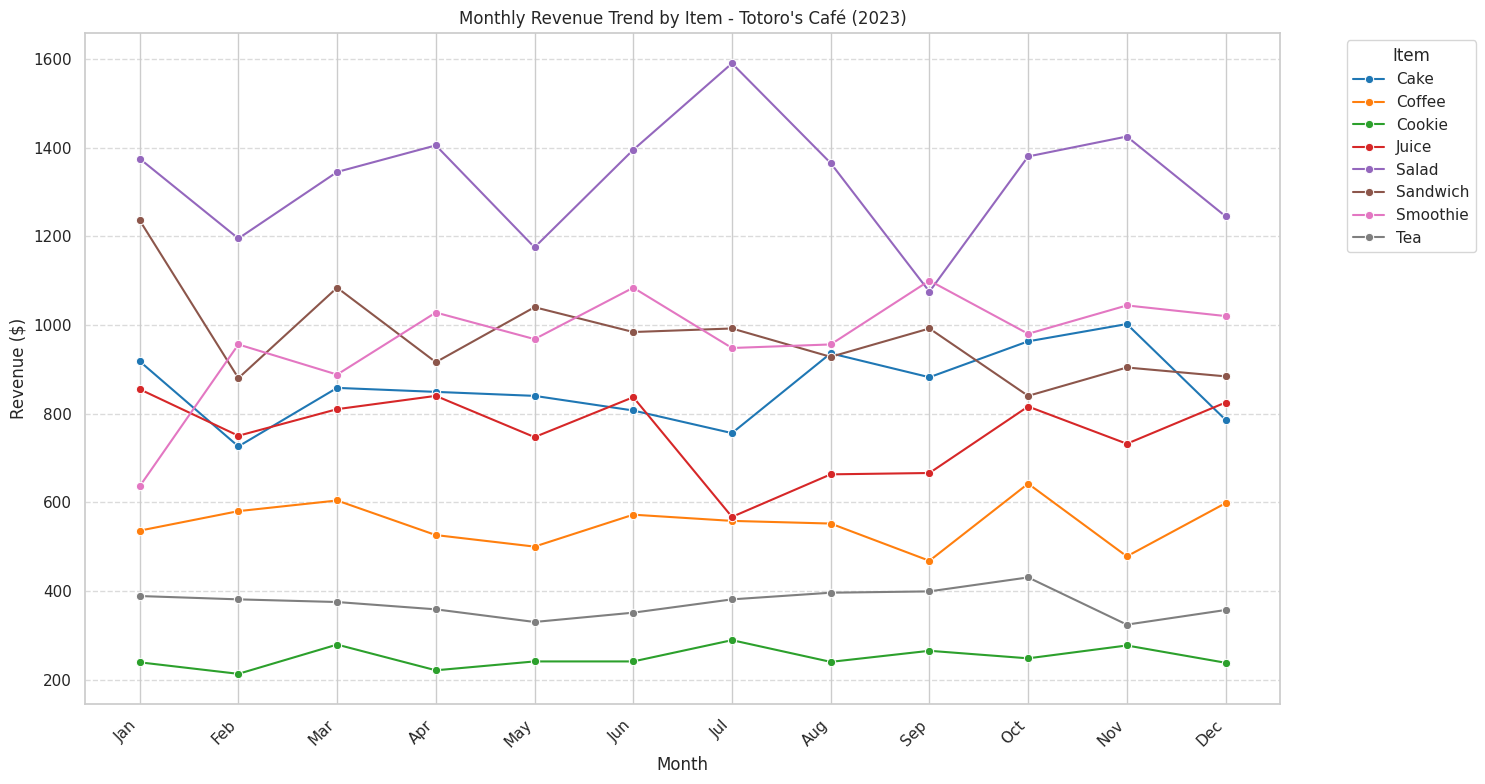

In [ ]:
# Graph: Item-Specific Revenue monthly trend
monthly_item_revenue = df_coff_shop.groupby(['month', 'month_name', 'item'])['total_spent_derived'].sum().reset_index()

plt.figure(figsize=(15, 8))
sns.lineplot(
    data=monthly_item_revenue,
    x='month_name',
    y='total_spent_derived',
    hue='item',
    marker='o',
    palette='tab10',
    sort=False # Ensure months are plotted in order
)

plt.title('Monthly Revenue Trend by Item - Totoro\'s Café (2023)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Item', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

*Is February a: Volume problem?*  

> Revenue Volume fall compared to January  
> First: "Sandwich"  
> Second: "Salad"   
> Third: "Cake"  
> Fourth: "Juice"  

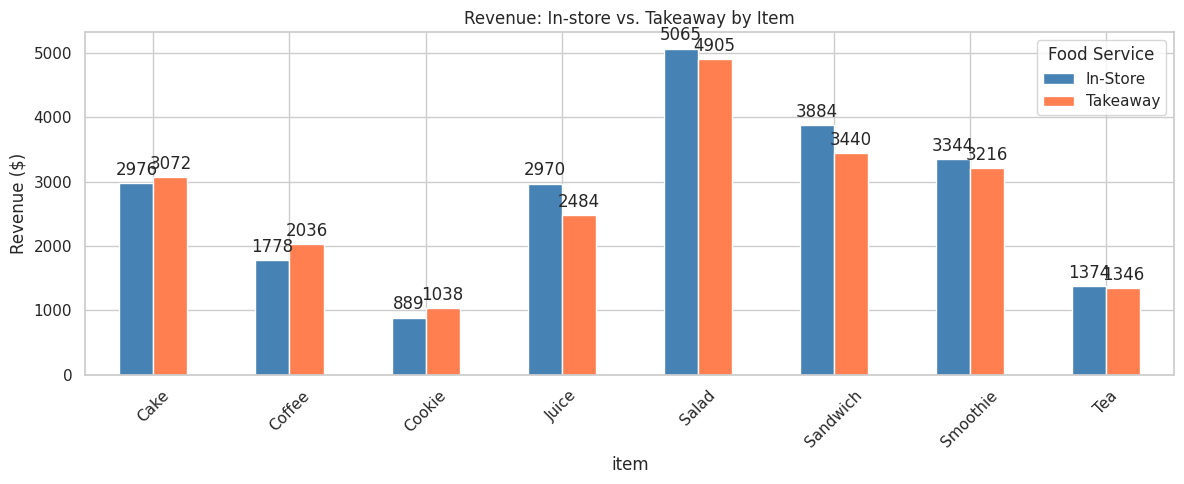


Avg basket by food_service:
food_service
In-store    9.00
Takeaway    8.72
Name: total_spent_derived, dtype: float64


In [ ]:
# Food Serving: In-Store vs Takeaway by Item
loc_item = df_coff_shop[
    df_coff_shop["food_service"].isin(["In-store", "Takeaway"])
]

# New Viz-Chart
pivot_loc = loc_item.groupby(["item", "food_service"])[[
    "total_spent_derived"
]].sum().unstack()


ax = pivot_loc.plot(kind="bar", figsize=(12, 5), color=["steelblue", "coral"])
plt.title("Revenue: In-store vs. Takeaway by Item")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.legend(title="Food Service", labels=["In-Store","Takeaway"])

# Add annotations to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

# Avg basket per food_service
print("\nAvg basket by food_service:")
print(loc_item.groupby("food_service")["total_spent_derived"].mean().round(2))

*Food Service per Item Preferance?*  

> Items that sell best In-Store: #1 Juice, #2 Sandwich, #3 Salad & Smoothie

> Items that sell best as Takeaway: #1 Coffee, #2 Cookie, #3 Cake

> Item that shows No Preference on its Food Serving delivery: Tea (only)




### Analytics Layer 3: Predictive -- What is likely to happen? and Who are our customers?

1. **Spending Tier Segmentation**.  
> K-Means clustering: to group transactions into **behavioral segments**
2. **Monthly Revenue Forecast**
> Simple **trend projection** for the next 3 months.

In [ ]:
# Build Transaction Features for Clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Feature engineering per transaction
features = df_coff_shop[["quantity", "price_per_unit", "total_spent_derived"]].copy()

# Scale features (K-Means is distance-based, scale matters)
scaler = StandardScaler()
# Calculates mean and std dev, then transforms the data
X_scaled = scaler.fit_transform(features)

print("Features ready for clustering:", features.shape)
features.describe().round(2)

Features ready for clustering: (8206, 3)


,quantity,price_per_unit,total_spent_derived
count,8206.00,8206.00,8206.00
mean,3.02,2.94,8.87
std,1.42,1.28,5.98
min,1.00,1.00,1.00
25%,2.00,2.00,4.00
50%,3.00,3.00,8.00
75%,4.00,4.00,12.00
max,5.00,5.00,25.00


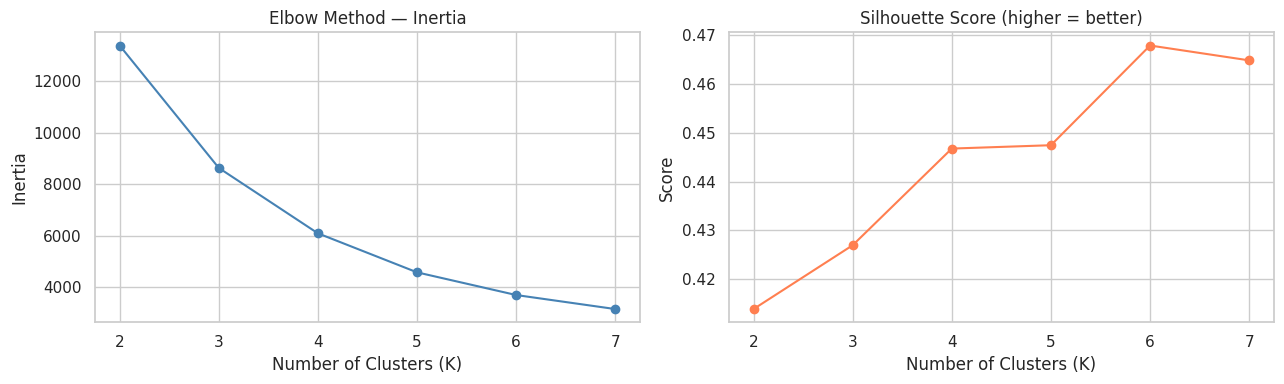


Silhouette Scores:
  K=2: 0.4139
  K=3: 0.4269
  K=4: 0.4468
  K=5: 0.4475
  K=6: 0.4679
  K=7: 0.4648


In [ ]:
# Find Optimal K (Elbow + Silhouette) = number of clusters
# KMeans is an unsupervised machine learning algorithm used for clustering.
# Looks for natural groupings based on how close data points are to each other.
inertias    = []
silhouettes = []
k_range     = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fit the model to your scaled data
    labels = km.fit_predict(X_scaled)
    # Measures how tightly grouped the data points are inside their cluster
    # Low-i: compact clusters, High-i: loose clusters
    inertias.append(km.inertia_)
    # Metric used to evaluate the quality of your clustering
    # +1: Excellent, 0: Overlapping ,-1: Bad
    silhouettes.append(silhouette_score(X_scaled, labels))

# New Viz-Graph
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method — Inertia")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouettes, marker="o", color="coral")
axes[1].set_title("Silhouette Score (higher = better)")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(k_range, silhouettes):
    print(f"  K={k}: {s:.4f}")

*Where does inertia stop dropping sharply? Where does silhouette peak? That's your K.*

> You are looking for the "elbow" of the curve—the point where the inertia stops dropping drastically and begins to flatten out.  
> That "elbow" point indicates the optimal number of clusters for your dataset.

> *To me it seems the best number of clusters to use is 6*.

In [ ]:
# Apply K-Means with Best K

# Replace K with what the elbow + silhouette suggest (likely 3)
BEST_K = 6

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_coff_shop["segment"] = km_final.fit_predict(X_scaled)

# Label by avg total_spent per cluster
seg_order = df_coff_shop.groupby("segment")["total_spent_derived"].mean().sort_values()
label_map = {seg: name for seg, name in zip(seg_order.index, ["Low-Spender1","Spender2", "Spender3","Spender4" ,"Spender5", "High-Spender6"])}
df_coff_shop["segment_label"] = df_coff_shop["segment"].map(label_map)


print(df_coff_shop["segment_label"].value_counts())

segment_label
Spender2         1843
Low-Spender1     1828
Spender3         1242
Spender5         1225
Spender4         1217
High-Spender6     851
Name: count, dtype: int64


In [ ]:
# Attempt to enforce Segment labeling order
# 2. Define your explicit ascending order
custom_order = [
    "Low-Spender1",
    "Spender2",
    "Spender3",
    "Spender4",
    "Spender5",
    "High-Spender6"
]

# 3. Create the categorical data type (set ordered=True)
cat_type = pd.CategoricalDtype(categories=custom_order, ordered=True)

# 4. Cast the column to this new categorical type
df_coff_shop['segment_label_order'] = df_coff_shop['segment_label'].astype(cat_type)

# 5. Sort the DataFrame by the Segment column
df_sorted = df_coff_shop.sort_values(by='segment_label_order', ascending=True)

print(df_sorted)

     transaction_id      item  quantity  price_per_unit  total_spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
4616    TXN_9833195    Coffee       2.0             2.0          4.0   
2063    TXN_8277553       Tea       3.0             1.5          4.5   
8865    TXN_4565969    Coffee       3.0             2.0          6.0   
2056    TXN_8426712    Cookie       3.0             1.0          3.0   
...             ...       ...       ...             ...          ...   
5028    TXN_3112013  Sandwich       5.0             4.0         20.0   
3895    TXN_5788053  Sandwich       5.0             4.0         20.0   
5040    TXN_8787350  Sandwich       5.0             4.0         20.0   
9172    TXN_4346813     Salad       5.0             5.0         25.0   
3217    TXN_9841222  Sandwich       5.0             4.0         20.0   

      payment_method food_service transaction_date  month month_name  \
0        Credit Card     Takeaway       2023-09-08    9.0      

In [ ]:
# Segment Profiles & Calc Metrics

seg_profile = df_coff_shop.groupby("segment_label_order", observed=False).agg(
    transactions    = ("transaction_id", "count"),
    avg_qty         = ("quantity", "mean"),
    avg_price       = ("price_per_unit", "mean"),
    avg_basket      = ("total_spent_derived", "mean"),
    total_revenue   = ("total_spent_derived", "sum")
).round(2)

seg_profile["revenue_share_%"] = (seg_profile["total_revenue"] / seg_profile["total_revenue"].sum() * 100).round(1)

display(seg_profile)

,transactions,avg_qty,avg_price,avg_basket,total_revenue,revenue_share_%
segment_label_order,,,,,,
Low-Spender1,1828,2.01,1.51,3.04,5557.0,7.6
Spender2,1843,1.45,3.65,5.22,9615.0,13.2
Spender3,1242,4.52,1.52,6.86,8519.5,11.7
Spender4,1217,2.82,3.97,11.03,13427.0,18.5
Spender5,1225,4.36,3.30,14.28,17497.0,24.0
High-Spender6,851,4.74,4.52,21.33,18150.0,24.9


*What are the avg basket sizes per segment?*

> * Spender 1  =  $ 3.05

> * Spender 2  =  $ 5.22

> * Spender 3  =  $ 6.86  

> * Spender 4  =  $ 11.03  

> * Spender 5  =  $ 14.28

> * Spender 6  =  $ 21.33

*What % of revenue does each drive?*

> * Spender 1  =  % 7.06

> * Spender 2  =  % 13.6

> * Spender 3  =  % 11.7  

> * Spender 4  =  % 18.5  

> * Spender 5  =  % 24

> * Spender 6  =  % 24.9

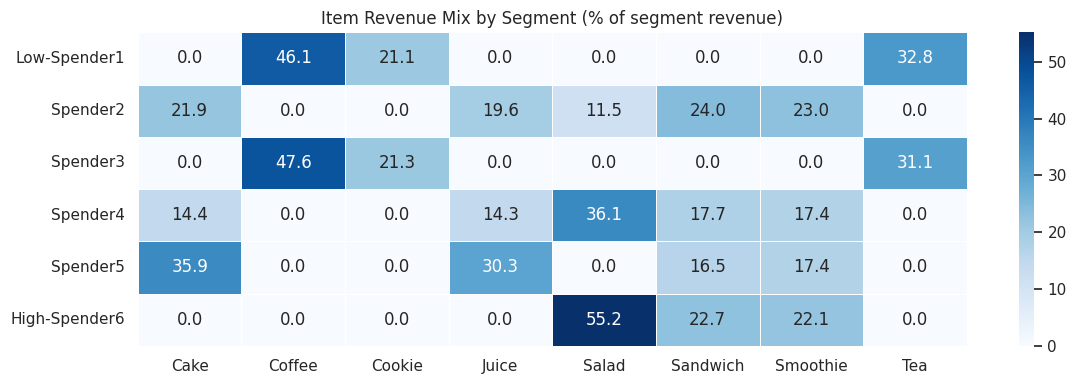

In [ ]:
# Segment x Item Heatmap

seg_item = df_coff_shop.groupby(["segment_label_order", "item"], observed=False)["total_spent_derived"].sum().unstack().fillna(0)
seg_item_pct = seg_item.div(seg_item.sum(axis=1), axis=0) * 100  # normalize per segment


# New Viz-Graph
plt.figure(figsize=(12, 4))
sns.heatmap(seg_item_pct.round(1), annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Item Revenue Mix by Segment (% of segment revenue)")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()

*Do High Spenders favor specific items (e.g., Salad, Smoothie)?*

> High Spenders purchase mostly `Salads`. Next on `Sandwiches`. And lastly, very close to the Sandwiches, `Smoothies`.

### Save Clean Dataset for Presentation Use

In [ ]:
df_coff_shop.to_csv("totoros_cafe_analyzed.csv", index=False)
print("Saved: totoros_cafe_analyzed.csv")
print(f"Final clean dataset: {len(df_coff_shop):,} rows, {df_coff_shops.columns.tolist()}")

Saved: totoros_cafe_analyzed.csv


NameError: name 'df_clean' is not defined

In [ ]:
## Resources

This analysis notebook utilized a variety of Python libraries, data manipulation techniques, visualization methods, and analytical approaches:

**Python Libraries:**
*   `pandas`: For data loading, manipulation, and analysis.
*   `numpy`: For numerical operations.
*   `matplotlib.pyplot`: For creating static, interactive, and animated visualizations.
*   `seaborn`: For high-level statistical data visualization.
*   `fg-data-profiling` (`data_profiling.ProfileReport`): For automated data profiling and exploratory data analysis reports.
*   `sklearn.preprocessing.StandardScaler`: For standardizing features for machine learning models.
*   `sklearn.cluster.KMeans`: For performing K-Means clustering.
*   `sklearn.metrics.silhouette_score`: For evaluating the quality of clusters.
*   `google.colab.files`: For uploading and downloading files in Google Colab.

**Data Handling and Preprocessing Techniques:**
*   **Data Loading:** Reading data from CSV (`pd.read_csv`).
*   **Column Standardization:** Lowercasing and replacing spaces in column names.
*   **Data Type Casting:** Converting columns to numeric and datetime types (`pd.to_numeric`, `pd.to_datetime`).
*   **Missing Value Handling:**
    *   Filling `NaN` values in categorical columns with "Unknown" (`.fillna()`).
    *   Dropping rows with `NaN` values in critical numerical columns (`.dropna()`).
    *   Unifying inconsistent representations of